In [2]:
import pandas as pd
from pathlib import Path
from neural_priors.utils.data import Subject, get_all_subject_ids, get_all_behavioral_data
from neural_priors.encoding_model.decode import get_decoding_paradigm
import numpy as np
from tqdm.notebook import tqdm
from tqdm.contrib.itertools import product
import pingouin as pg
import seaborn as sns
import matplotlib.pyplot as plt

bids_folder = Path('/data/ds-neuralpriors')

model_label = 31
spherical_noise = False

def get_pdf(subject, smoothed=False, model_label=4, fit_responses=False, n_voxels=100, spherical_noise=False):
    # Load subject
    sub = Subject(subject, bids_folder=bids_folder)

    # Create target folder
    key = f'model{model_label}'

    if smoothed:
        key += '.smoothed'

    if spherical_noise:
        key += '.spherical_noise'

    if fit_responses:
        key += '.fit_responses'

    target_dir = bids_folder / 'derivatives' / 'decoding2' / key / f'sub-{subject}' / 'func'

    # sub-04_mask-NPCr_nvoxels-100_pars.tsv
    pdf = pd.read_csv(target_dir / f'sub-{subject}_mask-NPCr_nvoxels-{n_voxels}_pars.tsv', sep='\t', index_col=[0,1], header=[0,1], )
    paradigm = get_decoding_paradigm(sub, fit_responses=fit_responses, drop_levels=False)
    pdf.index = paradigm.index

    pdf.set_index(paradigm['x'], append=True, inplace=True)
    pdf.set_index(paradigm['range'], append=True, inplace=True)

    pdf.columns.names = ['n', 'range']

    # Make first level of columns float 32
    new_columns = pd.MultiIndex.from_arrays([pdf.columns.get_level_values(0).astype(np.float32), pdf.columns.get_level_values(1)], names=pdf.columns.names)

    # Assign the new MultiIndex back to the DataFrame
    pdf.columns = new_columns

    return pdf

def summarize_pdf(pdf):
    pdf0 = pdf.xs('0.0', level=1, axis=1)
    
    pdf0 /= np.trapz(pdf0, pdf0.columns.astype(np.float32), axis=1)[:, np.newaxis]
    E0 = np.trapz(pdf0 * pdf0.columns.values.astype(float)[np.newaxis, :], pdf0.columns.astype(np.float32), axis=1)

    sd0 = np.trapz(np.abs(E0[:, np.newaxis] - pdf0.columns.values.astype(float)[np.newaxis, :]) * pdf0, pdf0.columns.astype(np.float32), axis=1)

    pdf1 = pdf.xs('1.0', level=1, axis=1)
    pdf1 /= np.trapz(pdf1, pdf1.columns.astype(np.float32), axis=1)[:, np.newaxis]
    E1 = np.trapz(pdf1 * pdf1.columns.values.astype(float)[np.newaxis, :], pdf1.columns.astype(np.float32), axis=1)
    sd1 = np.trapz(np.abs(E1[:, np.newaxis] - pdf1.columns.values.astype(float)[np.newaxis, :]) * pdf1, pdf1.columns.astype(np.float32), axis=1)

    ix_ = pd.IndexSlice

    pdf0_ = pdf0.loc[:, :25]
    pdf0_ /= np.trapz(pdf0_, pdf0_.columns.astype(np.float32), axis=1)[:, np.newaxis]

    E = np.where(pdf.index.get_level_values('range') == 0.0, E0, E1)
    sd = np.where(pdf.index.get_level_values('range') == 0.0, sd0, sd1)

    pars = pd.DataFrame(index=pdf.index, columns=['E', 'sd'])
    pars['E'] = E
    pars['sd'] = sd

    pars.reset_index(['x', 'range'], inplace=True)

    pars['error'] = pars['E'] - pars['x']
    pars['abs(error)'] = np.abs(pars['error'])

    return pars

In [105]:
subjects = get_all_subject_ids()

fit_responses = False
n_voxels = 0
spherical_noise = True
model_label = 31

pdfs = []
keys = []
pars = []

for subject, smoothed in product(subjects, [True]): 
    try:
        pdf = get_pdf(subject, smoothed=smoothed, model_label=model_label, fit_responses=fit_responses, n_voxels=n_voxels, spherical_noise=spherical_noise)
        pars_ = summarize_pdf(pdf)
        pdfs.append(pdf)
        keys.append((subject, smoothed))
        pars.append(pars_.droplevel('subject'))
    except FileNotFoundError as e:
        print(f'File not found for subject {subject}, smoothed={smoothed}, model_label={model_label}, fit_responses={fit_responses}, n_voxels={n_voxels}: {e}')
        continue
    except Exception as e:
        print(f'Error for subject {subject}, smoothed={smoothed}, model_label={model_label}, fit: {e}, {fit_responses}, (n_voxels={n_voxels})')
        continue

pdf = pd.concat(pdfs, keys=keys, names=['subject', 'smoothed'])
pars = pd.concat(pars, keys=keys, names=['subject', 'smoothed'])

pars['range'] = pars['range'].map({0.0: 'narrow', 1.0: 'wide'})

  0%|          | 0/39 [00:00<?, ?it/s]

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_69431/4034098467.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  r = pars.groupby(['subject', 'run', 'session', 'range']).apply(lambda d: pg.corr(d['E'], d['x'], method='pearson')).groupby(['subject', 'range']).mean(numeric_only=True)


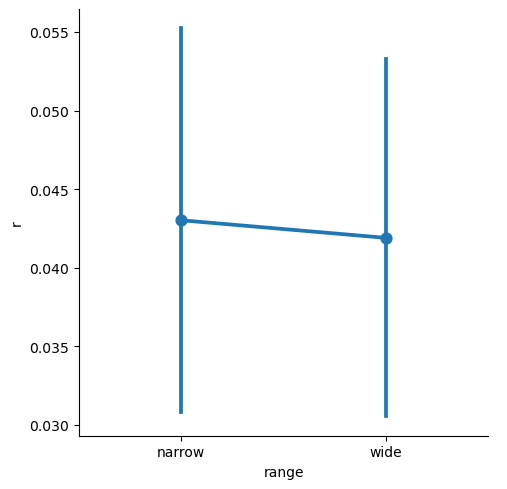

In [79]:
import pingouin as pg
r = pars.groupby(['subject', 'run', 'session', 'range']).apply(lambda d: pg.corr(d['E'], d['x'], method='pearson')).groupby(['subject', 'range']).mean(numeric_only=True)

sns.catplot(data=r.reset_index(), x='range', y='r', kind='point', errorbar='se')

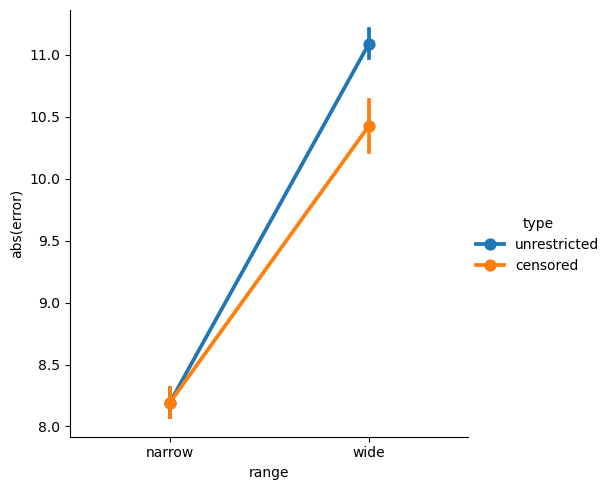

In [95]:
mean_abs_errors_unrestricted = pars.groupby(['subject', 'range']).mean(numeric_only=True).reset_index()
mean_abs_error_censored = pars[pars['x'] < 26].groupby(['subject', 'range']).mean(numeric_only=True).reset_index()
mean_abs_error = pd.concat([mean_abs_errors_unrestricted.assign(type='unrestricted'), mean_abs_error_censored.assign(type='censored')], ignore_index=True)

sns.catplot(x='range', y='abs(error)', hue='type', kind='point', errorbar='se', data=mean_abs_error)

In [100]:
mean_abs_error_censored.groupby(['subject', 'range'])['abs(error)'].mean().groupby('range').agg(['mean', 'std'])

,mean,std
range,,
narrow,8.192490,0.740163
wide,10.424685,1.322486


In [103]:
pg.pairwise_ttests(data=mean_abs_error_censored, dv='abs(error)', within='range', subject='subject')

/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/pingouin/pairwise.py:28: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwise_tests instead.", UserWarning)


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
0,range,narrow,wide,True,True,-10.78022,38.0,two-sided,4.061838e-13,1.958e+10,-2.062354


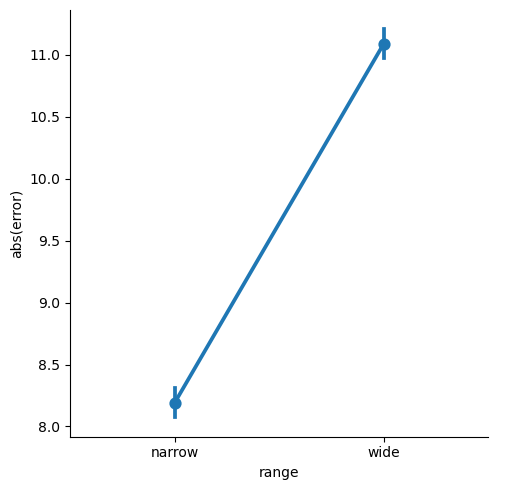

In [73]:
sns.catplot(x='range', y='abs(error)', kind='point', errorbar='se', data=pars.groupby(['subject', 'range']).mean())

In [ ]:
sns.catplot()

In [ ]:
pg.ttest(r['r'].unstack('range')['narrow'], r['r'].unstack('range')['wide'], paired=True)s

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,0.073237,38,two-sided,0.942002,"[-0.03, 0.03]",0.015185,0.173,0.05098


In [70]:
pg.ttest(r['r'].unstack('range')['narrow'], r['r'].unstack('range')['wide'], paired=True)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,0.073237,38,two-sided,0.942002,"[-0.03, 0.03]",0.015185,0.173,0.05098


In [61]:
pg.rm_corr(pars.reset_index(), x='E', y='x', subject='subject')

,r,dof,pval,CI95%,power
rm_corr,0.129741,18658,7.477440e-71,"[0.12, 0.14]",1.0


In [81]:
pars.groupby(['range']).apply(lambda d: pg.rm_corr(d.reset_index(), x='E', y='x', subject='subject'))

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_69431/453097392.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pars.groupby(['range']).apply(lambda d: pg.rm_corr(d.reset_index(), x='E', y='x', subject='subject'))


,,r,dof,pval,CI95%,power
range,,,,,,
narrow,rm_corr,0.045593,9320,0.000011,"[0.03, 0.07]",0.992750
wide,rm_corr,0.044085,9298,0.000021,"[0.02, 0.06]",0.989096


In [83]:
pars[pars['x'] < 26].groupby(['range']).apply(lambda d: pg.rm_corr(d.reset_index(), x='E', y='x', subject='subject'))

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_69431/1743743966.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pars[pars['x'] < 26].groupby(['range']).apply(lambda d: pg.rm_corr(d.reset_index(), x='E', y='x', subject='subject'))


,,r,dof,pval,CI95%,power
range,,,,,,
narrow,rm_corr,0.045593,9320,0.000011,"[0.03, 0.07]",0.992750
wide,rm_corr,0.035324,4822,0.014145,"[0.01, 0.06]",0.689334


In [90]:
tmp = pars[pars['x'] < 26].groupby(['subject', 'range']).apply(lambda d: pg.corr(d['E'], d['x'], method='pearson'))

pg.ttest(tmp.unstack('range')['r']['narrow'], tmp.unstack('range')['r']['wide'], paired=True)

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_69431/3095372400.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tmp = pars[pars['x'] < 26].groupby(['subject', 'range']).apply(lambda d: pg.corr(d['E'], d['x'], method='pearson'))


,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,0.309686,38,two-sided,0.758492,"[-0.03, 0.04]",0.070527,0.181,0.071379


In [94]:
tmp.groupby('range')['r'].mean()

range
narrow    0.043605
wide      0.037870
Name: r, dtype: float64